# 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Tratamento

### 2.1 Exclusão por Variáveis Qualitativas Críticas

In [2]:
df_raw = pd.read_csv("dataset.csv", sep=";", low_memory=False)
print(f"Dimensões originais do dataset: {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas\n")

# Remove observações com nulos nas variáveis vitais de categorização.
critical_cols = ['Data_da_Ocorrencia', 'Classificacao_da_Ocorrencia', 'Operacao']
df_clean = df_raw.dropna(subset=critical_cols).copy()

Dimensões originais do dataset: 5021 linhas e 45 colunas



### 2.2 Extração e Filtragem Temporal

In [3]:
# Extraindo o ano a partir da coluna de data.
# Certificando-se de que a coluna está no formato datetime.
df_clean['Data_da_Ocorrencia'] = pd.to_datetime(df_clean['Data_da_Ocorrencia'], errors='coerce')
df_clean['ANO_OCORRENCIA'] = df_clean['Data_da_Ocorrencia'].dt.year

# Filtra os anos que fornecem dados mais consistentes.
df_clean = df_clean[(df_clean['ANO_OCORRENCIA'] >= 1998) & (df_clean['ANO_OCORRENCIA'] <= 2022)].copy()

print(f"Dimensões do dataset tratado: {df_clean.shape[0]} linhas\n")
df_clean.head()

Dimensões do dataset tratado: 4441 linhas



,Numero_da_Ocorrencia,Numero_da_Ficha,Operador_Padronizado,Classificacao_da_Ocorrencia,Data_da_Ocorrencia,Hora_da_Ocorrencia,Municipio,UF,Regiao,Descricao_do_Tipo,...,Lesoes_Desconhecidas_Passageiros,Lesoes_Desconhecidas_Terceiros,Modelo,CLS,Tipo_ICAO,PMD,Numero_de_Assentos,Nome_do_Fabricante,PSSO,ANO_OCORRENCIA
0,5015,/2005,JOSE SEVERINO ENEAS CANDIDO,Acidente,2005-03-27,NaN,NaN,CE,Nordeste,NaN,...,0.0,0.0,EMB-720C,L1P,PA32,1542.0,7.0,NEIVA,verdadeiro,2005
1,5014,/2005,STILUS TAXI AEREO LTDA,Acidente,2005-03-19,NaN,NaN,Indeterminado,NaN,NaN,...,0.0,0.0,EMB-721C,L1P,P32R,1633.0,7.0,NEIVA,verdadeiro,2005
2,5013,/2005,AGROPENA AVIACAO AGRICOLA LTDA,Acidente,2005-03-18,NaN,NaN,Indeterminado,NaN,NaN,...,0.0,0.0,PA-25-260,L1P,PA25,1315.0,1.0,PIPER AIRCRAFT,verdadeiro,2005
3,5023,/2005,LEONARDO SUBTIL MARTINS ALMEIDA,Acidente,2005-05-27,NaN,NaN,Indeterminado,NaN,NaN,...,0.0,0.0,140A,L1P,C140,680.0,2.0,CESSNA AIRCRAFT,verdadeiro,2005
4,5012,/2005,MARISA MENDES DE OLIVEIRA,Acidente,2005-03-18,NaN,NaN,Indeterminado,NaN,NaN,...,0.0,0.0,172,L1P,C172,998.0,4.0,CESSNA AIRCRAFT,verdadeiro,2005


### 2.3 Agrupamento de Segmento de Aviação

In [4]:
# Identifica os 4 maiores segmentos
critical_sectors = ['Voo Privado', 'Operação Agrícola', 'Voo de Instrução', 'Táxi Aéreo']
# Tudo o que não for top 4 vira "Outros Segmentos"
df_clean['SEGMENTO_AGRUPADO'] = df_clean['Operacao'].apply(
    lambda x: x if x in critical_sectors else 'Outros Segmentos'
)

### 2.4 Imputação e Agrupamento das Lesões

In [5]:
colunas_fatais = ['Lesoes_Fatais_Tripulantes', 'Lesoes_Fatais_Passageiros', 'Lesoes_Fatais_Terceiros']
colunas_graves = ['Lesoes_Graves_Tripulantes', 'Lesoes_Graves_Passageiros', 'Lesoes_Graves_Terceiros']
colunas_leves  = ['Lesoes_Leves_Tripulantes', 'Lesoes_Leves_Passageiros', 'Lesoes_Leves_Terceiros']

# Tratamento de Nulos: Preenchendo com 0 todas as colunas envolvidas no cálculo
todas_colunas_lesoes = colunas_fatais + colunas_graves + colunas_leves
for col in todas_colunas_lesoes:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)
    else:
        # Cria a coluna com zero caso ela não exista por alguma divergência de nome
        df_clean[col] = 0

# Criação das métricas globais agregadas
df_clean['TOTAL_FATALIDADES'] = df_clean[colunas_fatais].sum(axis=1)
df_clean['TOTAL_LESIONADOS']  = df_clean[colunas_graves].sum(axis=1) + df_clean[colunas_leves].sum(axis=1)

### 2.5 Filtragem do Peso Máximo de Decolagem

In [6]:
df_clean['PMD'] = pd.to_numeric(df_clean['PMD'], errors='coerce')

n_antes = len(df_clean)

df_clean = df_clean[df_clean['PMD'] > 0].copy()

n_depois = len(df_clean)
print(f"--> [Metodologia] Removidos {n_antes - n_depois} registros com PMD inválido.")
print(f"--> [Amostra Consolidada] Novo tamanho estável da base (N) = {n_depois} registros.\n")

--> [Metodologia] Removidos 140 registros com PMD inválido.
--> [Amostra Consolidada] Novo tamanho estável da base (N) = 4301 registros.



# 3. Análise Unidimensional Qualitativa

### 3.1 Distribuição de Frequência para Classificação da Ocorrência

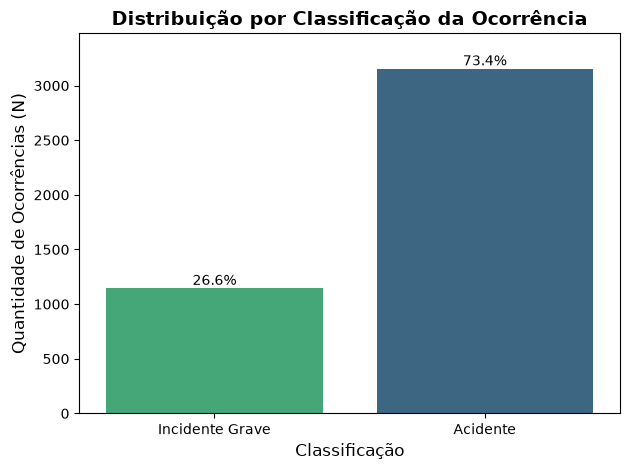

In [7]:
fig, ax = plt.subplots()

order = (
    df_clean['Classificacao_da_Ocorrencia']
    .value_counts()
    .sort_values()
    .index
)
sns.countplot(data=df_clean, x='Classificacao_da_Ocorrencia', hue='Classificacao_da_Ocorrencia', order=order, palette='viridis', legend=False, ax=ax)
ax.set_title('Distribuição por Classificação da Ocorrência', fontsize=14, fontweight='bold')
ax.set_xlabel('Classificação', fontsize=12)
ax.set_ylabel('Quantidade de Ocorrências (N)', fontsize=12)

ax.set_ylim(top=ax.get_ylim()[1] * 1.05)
length = len(df_clean)
for bar in ax.patches:
    height = bar.get_height()
    percent = 100 * height / length

    ax.annotate(
        f'{percent:.1f}%',
        (bar.get_x() + bar.get_width()/2, height),
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.show()

### 3.2 Distribuição de Frequência para Segmento de Aviação

In [8]:
freq_seg_abs = df_clean['Operacao'].value_counts()
freq_seg_rel = df_clean['Operacao'].value_counts(normalize=True) * 100

tab_segmento = pd.DataFrame({
    'Frequência Absoluta (N)': freq_seg_abs,
    'Frequência Relativa (%)': freq_seg_rel
})
print(tab_segmento.round(2))
print("\n" + "="*50 + "\n")

                        Frequência Absoluta (N)  Frequência Relativa (%)
Operacao                                                                
Voo Privado                                1956                    45.48
Operação Agrícola                           747                    17.37
Voo de Instrução                            704                    16.37
Táxi Aéreo                                  488                    11.35
Voo Regular                                 129                     3.00
Operação Pública                            119                     2.77
Operação Especializada                       98                     2.28
Voo Experimental                             38                     0.88
Voo não regular                               8                     0.19
Operação Policial                             8                     0.19
Desconhecida                                  6                     0.14




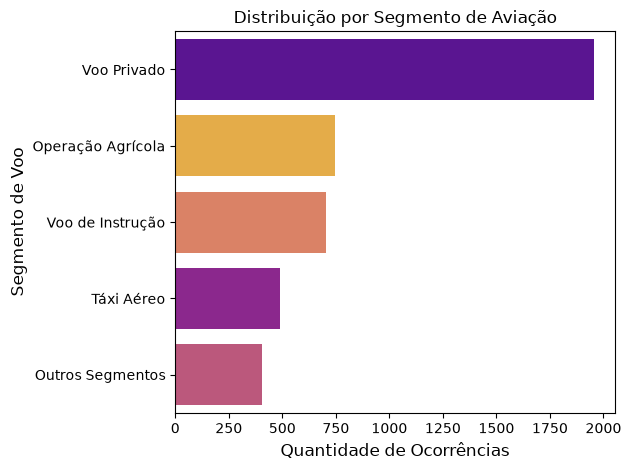

In [9]:
fig, ax = plt.subplots()

segmentos = df_clean['SEGMENTO_AGRUPADO'].value_counts().index
sns.countplot(data=df_clean,
              y='SEGMENTO_AGRUPADO', hue='SEGMENTO_AGRUPADO', palette='plasma', order=segmentos, legend=False)

ax.set_title('Distribuição por Segmento de Aviação')
ax.set_xlabel('Quantidade de Ocorrências', fontsize=12)
ax.set_ylabel('Segmento de Voo', fontsize=12)

plt.tight_layout()
plt.show()

### 3.3 Evolução Temporal

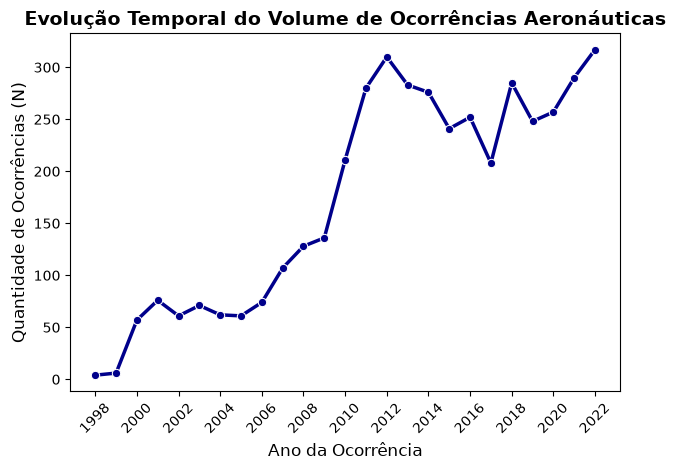

In [10]:
fig, ax = plt.subplots()
freq_year_abs = df_clean['ANO_OCORRENCIA'].value_counts().sort_index()
sns.lineplot(x=freq_year_abs.index, y=freq_year_abs.values, marker='o', color='darkblue', linewidth=2.5, ax=ax)

ax.set_title('Evolução Temporal do Volume de Ocorrências Aeronáuticas', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano da Ocorrência', fontsize=12)
ax.set_ylabel('Quantidade de Ocorrências (N)', fontsize=12)

plt.xticks(range(1998, 2023, 2), rotation=45)
plt.tight_layout()
plt.show()

# 4. Análise Unidimensional Quantitativa

In [11]:
print("="*60)
print("ESTATÍSTICA DESCRITIVA UNIDIMENSIONAL - BASE CONSOLIDADA")
print("="*60)

print(f"\n[Métricas: PMD (kg)] | N = {len(df_clean)}")
print(df_clean['PMD'].describe())
print(f"median        {df_clean['PMD'].median():.2f}")

print(f"\n[Métricas: TOTAL_LESIONADOS] | N = {len(df_clean)}")
print(df_clean['TOTAL_LESIONADOS'].describe())
print(f"median        {df_clean['TOTAL_LESIONADOS'].median():.2f}")

print(f"\n[Métricas: TOTAL_FATALIDADES] | N = {len(df_clean)}")
print(df_clean['TOTAL_FATALIDADES'].describe())
print(f"median        {df_clean['TOTAL_FATALIDADES'].median():.2f}")

ESTATÍSTICA DESCRITIVA UNIDIMENSIONAL - BASE CONSOLIDADA

[Métricas: PMD (kg)] | N = 4301
count      4301.000000
mean       3668.135085
std       13910.435012
min          35.000000
25%        1000.000000
50%        1633.000000
75%        2155.000000
max      346544.000000
Name: PMD, dtype: float64
median        1633.00

[Métricas: TOTAL_LESIONADOS] | N = 4301
count    4301.000000
mean        0.386422
std         1.062661
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        23.000000
Name: TOTAL_LESIONADOS, dtype: float64
median        0.00

[Métricas: TOTAL_FATALIDADES] | N = 4301
count    4301.000000
mean        0.444780
std         4.026255
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       199.000000
Name: TOTAL_FATALIDADES, dtype: float64
median        0.00


### 4.1 Distribuição de PMD

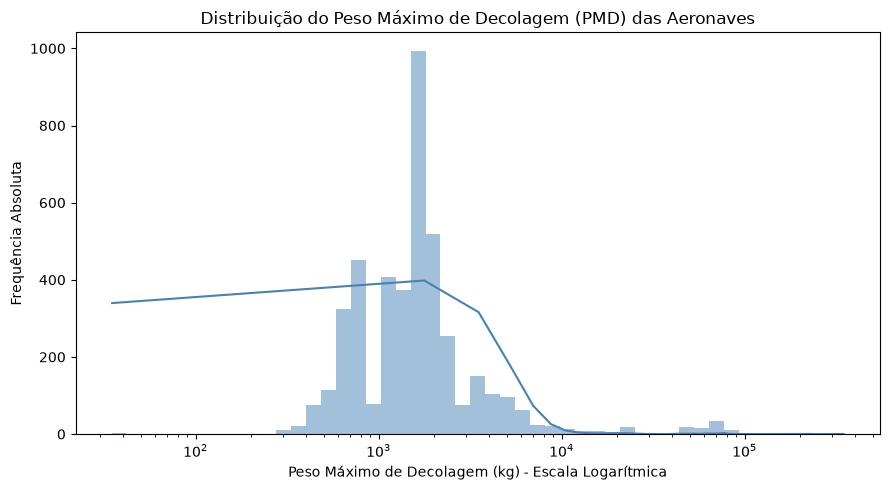

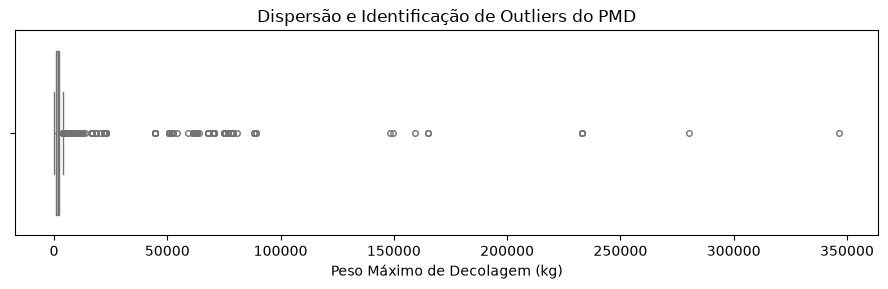

In [ ]:
plt.figure(figsize=(9, 5))
bins_log = np.logspace(np.log10(df_clean['PMD'].min()), 
                        np.log10(df_clean['PMD'].max()), 50)

sns.histplot(data=df_clean, x='PMD', bins=bins_log, color='steelblue', kde=True)
plt.xscale('log')
plt.title('Distribuição do Peso Máximo de Decolagem (PMD) das Aeronaves')
plt.xlabel('Peso Máximo de Decolagem (kg) - Escala Logarítmica')
plt.ylabel('Frequência Absoluta')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 3))
sns.boxplot(data=df_clean, x='PMD', color='lightskyblue', fliersize=4)
plt.title('Dispersão e Identificação de Outliers do PMD')
plt.xlabel('Peso Máximo de Decolagem (kg)')
plt.tight_layout()
plt.show()

### 4.2 Distribuição dos Danos Humanos

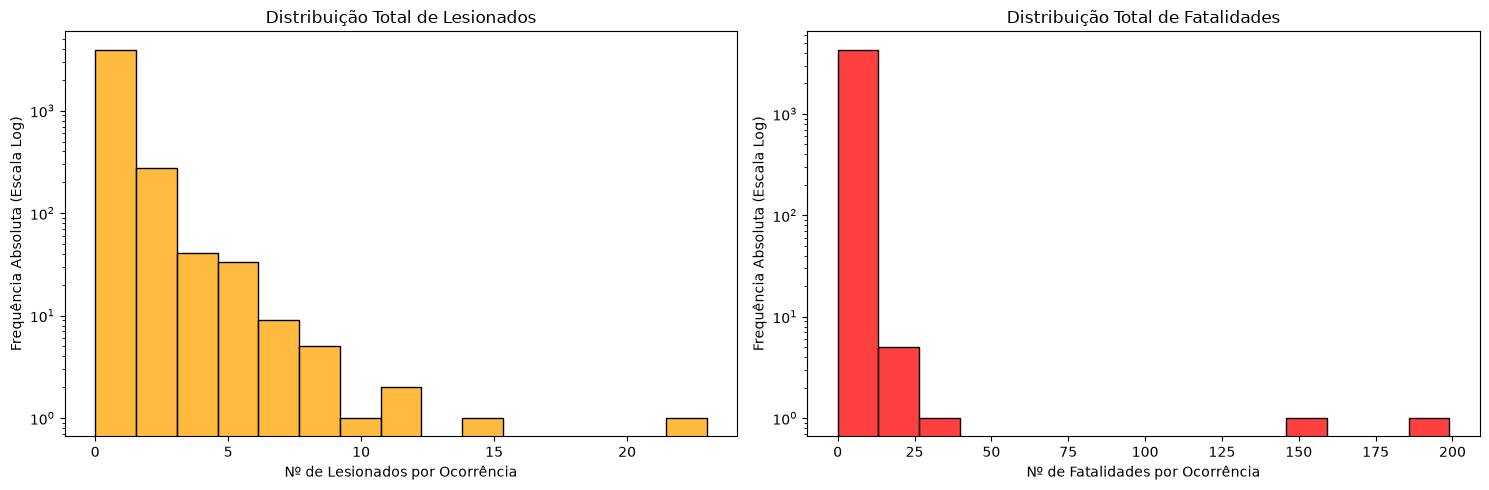

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df_clean, x='TOTAL_LESIONADOS', kde=False, bins=15, ax=axes[0], color='orange')
axes[0].set_title('Distribuição Total de Lesionados')
axes[0].set_xlabel('Nº de Lesionados por Ocorrência')
axes[0].set_ylabel('Frequência Absoluta (Escala Log)')
axes[0].set_yscale('log')

sns.histplot(data=df_clean, x='TOTAL_FATALIDADES', kde=False, bins=15, ax=axes[1], color='red')
axes[1].set_title('Distribuição Total de Fatalidades')
axes[1].set_xlabel('Nº de Fatalidades por Ocorrência')
axes[1].set_ylabel('Frequência Absoluta (Escala Log)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()